In [150]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [151]:
X, y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state = 13)

In [152]:
X1 = X.reshape(-1, 1)
y1 = y.reshape(-1, 1)


In [ ]:
df1 = pd.DataFrame(data = X1, columns = ["X"])
df2 = pd.DataFrame(data = y1, columns = ["y"])
df = pd.concat(objs = [df1, df2], axis = 1)
df

,X,y
0,-0.712391,-34.319881
1,-0.437146,-9.421210
2,-0.453752,-19.088188
3,0.952831,20.437212
4,0.237858,27.755966
...,...,...
95,-0.314858,-27.979066
96,1.849613,64.179470
97,-1.120507,-60.715439
98,-0.332676,22.233365


<Axes: xlabel='X', ylabel='y'>

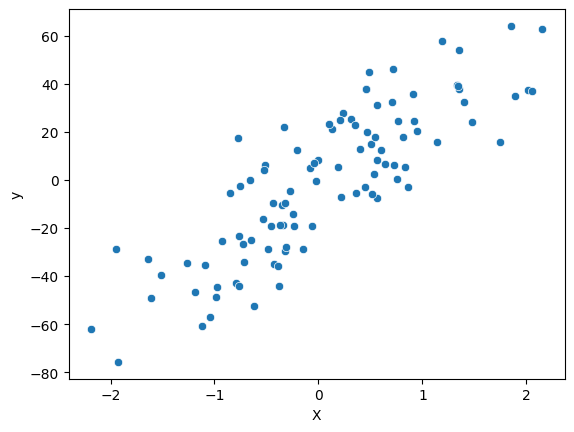

In [154]:
sns.scatterplot(data = df, x = 'X', y = 'y')

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

Ordinary Least Squares (OLS):

In [156]:
sk_ols = LinearRegression()
sk_ols.fit(X_train, y_train)
print(f"B0, {sk_ols.intercept_} and B1, {sk_ols.coef_}")

B0, -2.2710144261783825 and B1, [28.12597332]


Now by Gradient Descent (GD):

In [ ]:
class GDRegressorForSLR:
    def __init__(self,learning_rate,epochs):
        self.coef_ = 100
        self.intercept_ = -120
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self, X_train, y_train):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_coef_ = -2 * np.sum(y - self.coef_ * X.ravel() - self.intercept_)
            loss_slope_coef_ = -2 * np.sum((y - self.coef_ * X.ravel() - self.intercept_) * X.ravel())
            
            self.intercept_ = self.intercept_ - (self.lr * loss_slope_coef_)
            self.coef_ = self.coef_ - (self.lr * loss_slope_coef_)
        
    def fit2(self, X_train, y_train):
        #picking any random value for b0 and b1
        self.intercept_ = 5
        self.coef_ = 10

        flag = True
        while flag:
            partial_of_b0 = -2 * np.sum(y - self.coef_ * X.ravel() - self.intercept_)
            partial_of_b1 = -2 * np.sum((y - self.coef_ * X.ravel() - self.intercept_) * X.ravel())
            if partial_of_b0 == 0.1 and partial_of_b1 == 0.1:
                flag = False
            self.intercept_ = self.intercept_ - self.lr * partial_of_b0

            self.coef_ = self.coef_ - self.lr * partial_of_b1
            
    

In [183]:
my_GDR = GDRegressorForSLR(learning_rate = 0.001, epochs = 50)
my_GDR.fit(X_train = X_train, y_train = y_train)

#my_GDR.fit2(X_train = X_train, y_train = y_train)


In [184]:
print(f"My B0: {my_GDR.intercept_}, B1: {my_GDR.coef_}")
print(f"B0, {sk_ols.intercept_} and B1, {sk_ols.coef_}")

My B0: -2.2991839308293196, B1: 27.837060471820052
B0, -2.2710144261783825 and B1, [28.12597332]
